In [1]:
import numpy as np
import matplotlib.pyplot as plt
from poisson_model import compute_poisson_parameters, compare_poisson_parameters, generate_poisson_events, add_noise_to_events

## Искусственные данные

In [2]:
np.random.seed(42)
# Истинные параметры
lambda_true = 0.5
T = 100

# Генерация "чистых" событий
events_true = generate_poisson_events(lambda_true, T)

# Добавляем шум
events_noisy = add_noise_to_events(events_true,
                                    miss_prob=0.2,
                                    false_rate=0.2,
                                    T=T)

# Оценка параметров
params_true = compute_poisson_parameters(events_true)
params_noisy = compute_poisson_parameters(events_noisy)

comparison = compare_poisson_parameters(events_true, events_noisy)

print("=== TRUE DATA ===")
print(params_true)

print("\n=== NOISY DATA ===")
print(params_noisy)

print("\n=== COMPARISON ===")
print(comparison)

=== TRUE DATA ===
{'lambda': 0.544720392676221, 'lambda_std': 0.07553912717634591, 'mean_interarrival': 1.835804228086601, 'n_events': 52, 'total_time': 93.62601563241667, 'interarrival_std': 1.9027377927065252, 'cv': 1.0364600776029844, 'dispersion_index': 0.3686274509803922, 'stationarity_pvalue': 0.8311469396503227}

=== NOISY DATA ===
{'lambda': 0.501997224623184, 'lambda_std': 0.07245705819216008, 'mean_interarrival': 1.9920428857960992, 'n_events': 48, 'total_time': 93.62601563241667, 'interarrival_std': 1.7110650649486547, 'cv': 0.8589499137539127, 'dispersion_index': 0.14361702127659576, 'stationarity_pvalue': 0.9337981776291111}

=== COMPARISON ===
{'lambda_true': 0.544720392676221, 'lambda_noisy': 0.501997224623184, 'delta_lambda': 0.042723168053037}


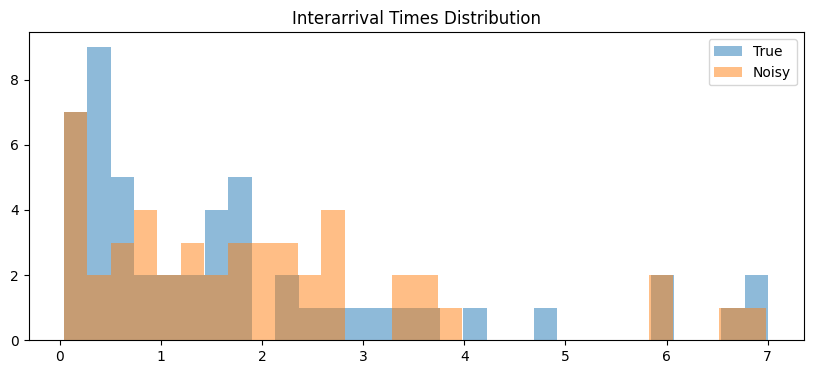

In [3]:
# Визуализация
plt.figure(figsize=(10, 4))

plt.hist(np.diff(events_true), bins=30, alpha=0.5, label="True")
plt.hist(np.diff(events_noisy), bins=30, alpha=0.5, label="Noisy")

plt.legend()
plt.title("Interarrival Times Distribution")
plt.show()

## Данные из Mall Dataset

In [4]:
import sys
import os
sys.path.append(os.path.abspath('../..'))
from mall_dataset.events_extractor import load_mall_ground_truth, extract_event_timestamps, get_frame_timestamps, extract_significant_events

counts = load_mall_ground_truth("../../mall_dataset/mall_gt.mat")
print(f"Всего кадров: {len(counts)}")
print(f"Диапазон количества людей: от {min(counts)} до {max(counts)}")
print(f"Среднее количество людей: {np.mean(counts):.2f}\n")

# # Извлечение событий
# events = extract_event_timestamps(counts)
# Извлечение значимых событий
events = extract_significant_events(counts, threshold=3)
print(f"Всего событий: {len(events)}\n")

# Вывод первых 10 событий
print("Первые 10 событий:")
print("Кадр\tКол-во\tСобытие\tΔ")
for frame, count, event_type, delta in events[:10]:
    print(f"{frame}\t{count}\t{event_type}\t+{delta}" if event_type == 'enter' else f"{frame}\t{count}\t{event_type}\t{delta}")

# Временные метки (если известен FPS)
print("\n--- Временные метки (предполагая FPS=25) ---")
events_list = get_frame_timestamps("../../mall_dataset/mall_gt.mat", fps=1, significant_events=True, threshold=3)
for ts in events_list[:10]:
    print(f"Кадр {ts['frame']:4d} | {ts['timestamp_str']} | Людей: {ts['people_count']:3d} | {ts['event']} ({ts['change']})")

Всего кадров: 2000
Диапазон количества людей: от 13 до 53
Среднее количество людей: 31.16

Всего событий: 622

Первые 10 событий:
Кадр	Кол-во	Событие	Δ
2	35	increase	6
3	31	decrease	4
4	26	decrease	5
8	29	increase	3
10	37	increase	8
12	41	increase	4
17	44	increase	3
18	36	decrease	8
22	40	increase	4
24	37	decrease	3

--- Временные метки (предполагая FPS=25) ---
Кадр    2 | 0:02.00 | Людей:  35 | increase (6)
Кадр    3 | 0:03.00 | Людей:  31 | decrease (4)
Кадр    4 | 0:04.00 | Людей:  26 | decrease (5)
Кадр    8 | 0:08.00 | Людей:  29 | increase (3)
Кадр   10 | 0:10.00 | Людей:  37 | increase (8)
Кадр   12 | 0:12.00 | Людей:  41 | increase (4)
Кадр   17 | 0:17.00 | Людей:  44 | increase (3)
Кадр   18 | 0:18.00 | Людей:  36 | decrease (8)
Кадр   22 | 0:22.00 | Людей:  40 | increase (4)
Кадр   24 | 0:24.00 | Людей:  37 | decrease (3)


### Проверим на Пуассоновость

АНАЛИЗ ОБЩЕГО ПОТОКА СОБЫТИЙ
Всего событий (любых изменений): 622
Первое событие: 2.00 сек
Последнее событие: 1997.00 сек
Длительность наблюдения: 1995.00 сек

ОЦЕНЕННЫЕ ПАРАМЕТРЫ:
  • λ (интенсивность) = 0.3113 событий/сек
  • Средний интервал между событиями = 3.2126 сек
  • Стандартное отклонение интервалов = 2.5137 сек
  • Коэффициент вариации = 0.7825
    (1 = идеальный пуассон, >1 = кластеризация, <1 = регулярность)
  • Индекс дисперсии = 1.3058
    (1 = пуассон, >1 = кластеризация, <1 = регулярность)

ПРОВЕРКА СВОЙСТВ:
  • Минимальный интервал: 1.0000 сек
  • Максимальный интервал: 18.0000 сек
  • Медианный интервал: 2.0000 сек
  • KS-тест на экспоненциальность: p-value = 0.0000
    ✗ Интервалы НЕ экспоненциальны (модель не подходит)


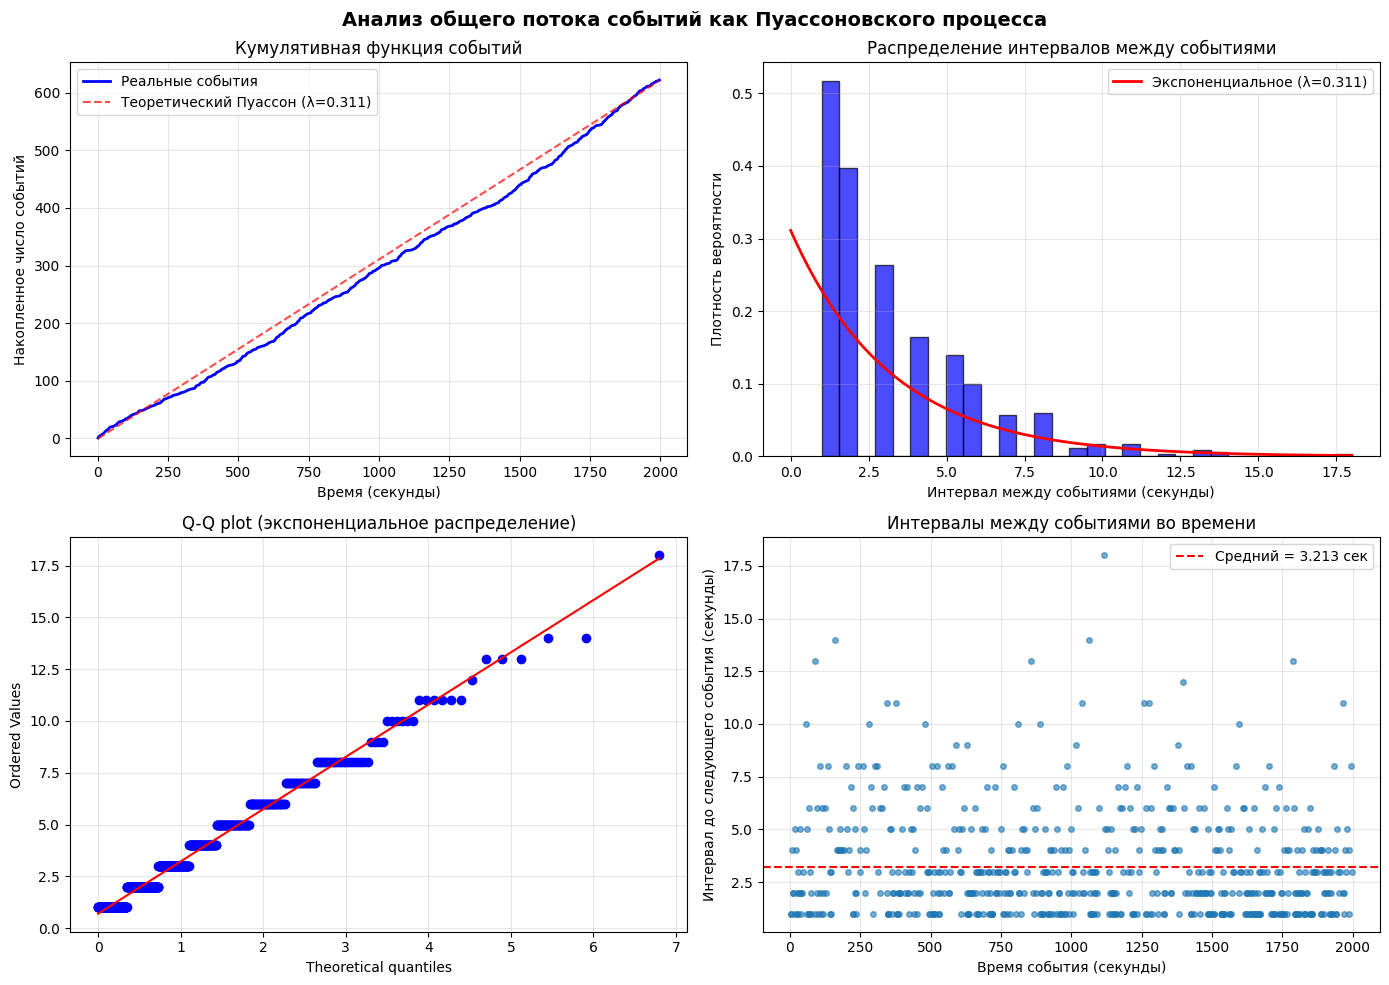


ВЕРДИКТ О ПРИМЕНИМОСТИ ПУАССОНОВСКОЙ МОДЕЛИ
✗ Коэффициент вариации далек от 1 (CV = 0.782)
✗ Индекс дисперсии далек от 1 (DI = 1.306)
✗ Интервалы не экспоненциальны (p-value = 0.0000)

РЕКОМЕНДАЦИЯ:
  ⚠️ Пуассоновская модель ПЛОХО описывает ваш поток событий
  • События слишком регулярны (неестественно для случайного потока)
  • Рассмотрите альтернативные модели: нестационарный Пуассон, процесс восстановления


In [5]:
# Извлекаем ТОЛЬКО временные метки
timestamps = np.array([event['timestamp_sec'] for event in events_list])
# poiss_events = np.array([timestamp['timestamp_sec'] for timestamp in timestamps])

# Базовый анализ общего потока
print("="*60)
print("АНАЛИЗ ОБЩЕГО ПОТОКА СОБЫТИЙ")
print("="*60)
print(f"Всего событий (любых изменений): {len(timestamps)}")
print(f"Первое событие: {timestamps[0]:.2f} сек")
print(f"Последнее событие: {timestamps[-1]:.2f} сек")
print(f"Длительность наблюдения: {timestamps[-1] - timestamps[0]:.2f} сек")

# Оценка параметров Пуассона
params = compute_poisson_parameters(timestamps)

print(f"\nОЦЕНЕННЫЕ ПАРАМЕТРЫ:")
print(f"  • λ (интенсивность) = {params['lambda']:.4f} событий/сек")
print(f"  • Средний интервал между событиями = {params['mean_interarrival']:.4f} сек")
print(f"  • Стандартное отклонение интервалов = {params['interarrival_std']:.4f} сек")
print(f"  • Коэффициент вариации = {params['cv']:.4f}")
print(f"    (1 = идеальный пуассон, >1 = кластеризация, <1 = регулярность)")

if 'dispersion_index' in params:
    print(f"  • Индекс дисперсии = {params['dispersion_index']:.4f}")
    print(f"    (1 = пуассон, >1 = кластеризация, <1 = регулярность)")

# Проверка свойств пуассоновского потока
interarrival = np.diff(timestamps)
print(f"\nПРОВЕРКА СВОЙСТВ:")
print(f"  • Минимальный интервал: {np.min(interarrival):.4f} сек")
print(f"  • Максимальный интервал: {np.max(interarrival):.4f} сек")
print(f"  • Медианный интервал: {np.median(interarrival):.4f} сек")

# Тест на экспоненциальность (если событий достаточно)
if len(interarrival) > 5:
    from scipy import stats
    ks_stat, ks_pvalue = stats.kstest(interarrival, 'expon', args=(0, params['mean_interarrival']))
    print(f"  • KS-тест на экспоненциальность: p-value = {ks_pvalue:.4f}")
    if ks_pvalue > 0.05:
        print(f"    ✓ Интервалы распределены экспоненциально (модель подходит)")
    else:
        print(f"    ✗ Интервалы НЕ экспоненциальны (модель не подходит)")

# ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Кумулятивный график событий
ax1 = axes[0, 0]
cumulative = np.arange(1, len(timestamps) + 1)
ax1.plot(timestamps, cumulative, 'b-', linewidth=2, label='Реальные события')
t_range = np.linspace(timestamps[0], timestamps[-1], 100)
theoretical = params['lambda'] * (t_range - timestamps[0])
ax1.plot(t_range, theoretical, 'r--', alpha=0.7, label=f'Теоретический Пуассон (λ={params["lambda"]:.3f})')
ax1.set_xlabel('Время (секунды)')
ax1.set_ylabel('Накопленное число событий')
ax1.set_title('Кумулятивная функция событий')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Гистограмма интервалов между событиями
ax2 = axes[0, 1]
ax2.hist(interarrival, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
# Теоретическое экспоненциальное распределение
x = np.linspace(0, max(interarrival), 100)
theoretical_pdf = params['lambda'] * np.exp(-params['lambda'] * x)
ax2.plot(x, theoretical_pdf, 'r-', linewidth=2, label=f'Экспоненциальное (λ={params["lambda"]:.3f})')
ax2.set_xlabel('Интервал между событиями (секунды)')
ax2.set_ylabel('Плотность вероятности')
ax2.set_title('Распределение интервалов между событиями')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Q-Q plot для проверки экспоненциальности
ax3 = axes[1, 0]
from scipy import stats
stats.probplot(interarrival, dist="expon", plot=ax3)
ax3.set_title('Q-Q plot (экспоненциальное распределение)')
ax3.grid(True, alpha=0.3)

# 4. Интервалы между событиями по времени (для поиска паттернов)
ax4 = axes[1, 1]
ax4.plot(timestamps[1:], interarrival, 'o', markersize=4, alpha=0.6)
ax4.axhline(y=params['mean_interarrival'], color='r', linestyle='--', label=f'Средний = {params["mean_interarrival"]:.3f} сек')
ax4.set_xlabel('Время события (секунды)')
ax4.set_ylabel('Интервал до следующего события (секунды)')
ax4.set_title('Интервалы между событиями во времени')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Анализ общего потока событий как Пуассоновского процесса', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ИТОГОВЫЙ ВЕРДИКТ
print("\n" + "="*60)
print("ВЕРДИКТ О ПРИМЕНИМОСТИ ПУАССОНОВСКОЙ МОДЕЛИ")
print("="*60)

# Простая оценка пригодности
cv = params['cv']
if 0.8 <= cv <= 1.2:
    print("✓ Коэффициент вариации в норме (CV ≈ 1)")
else:
    print(f"✗ Коэффициент вариации далек от 1 (CV = {cv:.3f})")

if 'dispersion_index' in params:
    di = params['dispersion_index']
    if 0.8 <= di <= 1.2:
        print("✓ Индекс дисперсии в норме (≈ 1)")
    else:
        print(f"✗ Индекс дисперсии далек от 1 (DI = {di:.3f})")

if len(interarrival) > 5:
    if ks_pvalue > 0.05:
        print("✓ Интервалы экспоненциальны (p-value > 0.05)")
    else:
        print(f"✗ Интервалы не экспоненциальны (p-value = {ks_pvalue:.4f})")

print("\nРЕКОМЕНДАЦИЯ:")
if 0.8 <= cv <= 1.2 and (len(interarrival) <= 5 or ks_pvalue > 0.05):
    print("  ✅ Пуассоновская модель ПРИМЕНИМА для описания общего потока событий")
    print(f"  Используйте λ = {params['lambda']:.4f} событий/сек")
else:
    print("  ⚠️ Пуассоновская модель ПЛОХО описывает ваш поток событий")
    if cv > 1.2:
        print("  • События имеют тенденцию к кластеризации (люди приходят/уходят группами)")
    elif cv < 0.8:
        print("  • События слишком регулярны (неестественно для случайного потока)")
    print("  • Рассмотрите альтернативные модели: нестационарный Пуассон, процесс восстановления")

In [6]:
# Оценка параметров
poiss_events = np.array([event['timestamp_sec'] for event in events_list])
params_true = compute_poisson_parameters(poiss_events)

print("=== TRUE DATA ===")
print(params_true)

=== TRUE DATA ===
{'lambda': 0.3112781954887218, 'lambda_std': 0.012481118536186277, 'mean_interarrival': 3.21256038647343, 'n_events': 622, 'total_time': 1995.0, 'interarrival_std': 2.5137118428014196, 'cv': 0.7824636864058554, 'dispersion_index': 1.3057971014492753, 'stationarity_pvalue': 0.22764386333400766}


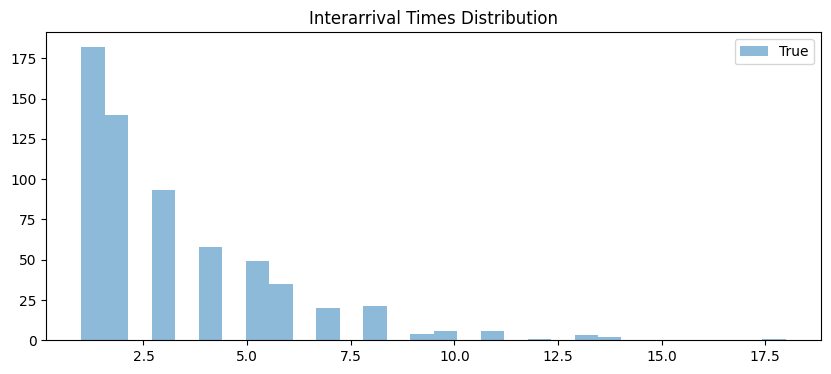

In [7]:
# Визуализация
plt.figure(figsize=(10, 4))

plt.hist(np.diff(poiss_events), bins=30, alpha=0.5, label="True")

plt.legend()
plt.title("Interarrival Times Distribution")
plt.show()

### Процесс Бернулли

In [21]:
from bernoulli_model import compute_bernoulli_parameters, test_bernoulli_assumptions, visualize_bernoulli_process
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


# Получаем события из аннотаций
events_list = get_frame_timestamps("../../mall_dataset/mall_gt.mat", fps=1, significant_events=True, threshold=3)

# Извлекаем временные метки (которые теперь совпадают с номерами кадров при fps=1)
timestamps_sec = np.array([event['timestamp_sec'] for event in events_list])

# При fps=1 timestamp_sec = номер кадра, поэтому event_frames = timestamps_sec
event_frames = timestamps_sec.astype(int)
total_frames = len(counts)  

print(f"Исходные данные:")
print(f"  Всего событий: {len(event_frames)}")
print(f"  Диапазон кадров: от {event_frames[0]} до {event_frames[-1]}")
print(f"  Общее количество кадров: {total_frames}")

# Оценка параметров Бернулли
params = compute_bernoulli_parameters(event_frames, total_frames)

print("\n" + "="*60)
print("ПАРАМЕТРЫ ПРОЦЕССА БЕРНУЛЛИ")
print("="*60)
print(f"  p (вероятность события в кадре) = {params['p']:.6f}")
print(f"  Стандартная ошибка p = {params['p_std']:.6f}")
print(f"  95% доверительный интервал: [{params['p_ci_lower']:.4f}, {params['p_ci_upper']:.4f}]")
print(f"  Средний интервал (кадры) = {params['mean_interval_frames']:.2f}")
print(f"  Теоретический средний интервал = {params['theoretical_mean_interval']:.2f}")
print(f"  Коэффициент вариации = {params['cv']:.4f}")

if 'stationarity_pvalue' in params:
    print(f"\n  Стационарность (p-value) = {params['stationarity_pvalue']:.4f}")
    if params['stationarity_pvalue'] > 0.05:
        print("    ✓ p можно считать постоянным во времени")
    else:
        print("    ✗ p значимо меняется во времени")

Исходные данные:
  Всего событий: 622
  Диапазон кадров: от 2 до 1997
  Общее количество кадров: 2000

ПАРАМЕТРЫ ПРОЦЕССА БЕРНУЛЛИ
  p (вероятность события в кадре) = 0.311000
  Стандартная ошибка p = 0.010351
  95% доверительный интервал: [0.2907, 0.3313]
  Средний интервал (кадры) = 3.21
  Теоретический средний интервал = 3.22
  Коэффициент вариации = 0.7825

  Стационарность (p-value) = 0.1265
    ✓ p можно считать постоянным во времени



=== Проверка свойств процесса Бернулли для Mall Dataset ===
  Хи-квадрат тест на геометрическое распределение:
    statistic=9.8896, p-value=0.6256
    ✓ Интервалы соответствуют геометрическому распределению

  Коэффициент вариации интервалов: 0.7825
    ⚠️ CV < 0.8 (недодисперсия, события слишком регулярны)

  Автокорреляция интервалов: 0.0924
    ✓ Слабая корреляция (интервалы независимы)

  Индекс дисперсии интервалов: 1.9669
    (1 = геометрическое, >1 = кластеризация, <1 = регулярность)


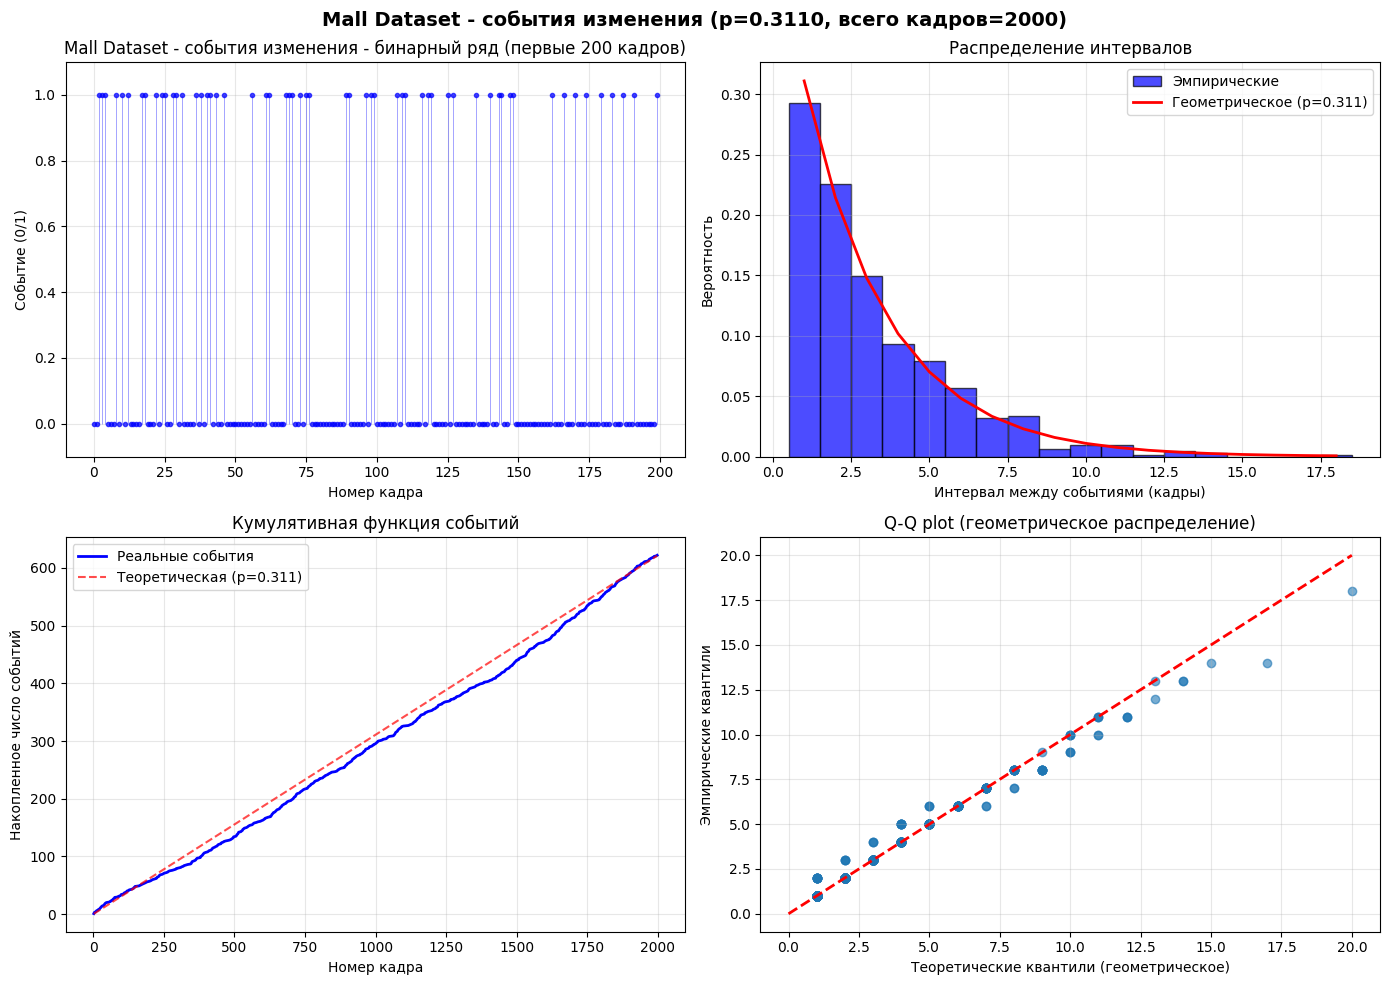


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
  Вероятность изменения в кадре: 31.10%
  В среднем 1 изменение каждые 3.2 кадров
  При FPS=1 это означает изменение каждые 3.2 секунд


In [22]:
# Проверка свойств
test_bernoulli_assumptions(event_frames, total_frames, "Mall Dataset")

# Визуализация
visualize_bernoulli_process(event_frames, total_frames, "Mall Dataset - события изменения")

# Дополнительная информация
print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)
print(f"  Вероятность изменения в кадре: {params['p']*100:.2f}%")
print(f"  В среднем 1 изменение каждые {params['mean_interval_frames']:.1f} кадров")
print(f"  При FPS=1 это означает изменение каждые {params['mean_interval_frames']:.1f} секунд")
